# Laboratorio 8
CC3094 Security Data Science  
Sección 10  
Erick Stiv Junior Guerra Muñoz - 21781  
  
Repositorio de GitHub: https://github.com/erickguerra22/SDS_Lab8.git

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import os
import matplotlib.image as mpimg
import random
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

1. En el preprocesamiento debe mostrar cuantos ejemplares hay por cada familia. En base a
estos datos debe determinar si considera pertinente prescindir de ejemplares que tengan
pocas observaciones.

Allaple.A: 2949 imágenes
Allaple.L: 1591 imágenes
Yuner.A: 800 imágenes
Instantaccess: 431 imágenes
VB.AT: 408 imágenes
Fakerean: 381 imágenes
Lolyda.AA1: 213 imágenes
C2LOP.gen!g: 200 imágenes
Alueron.gen!J: 198 imágenes
Lolyda.AA2: 184 imágenes
Dialplatform.B: 177 imágenes
Dontovo.A: 162 imágenes
Lolyda.AT: 159 imágenes
Rbot!gen: 158 imágenes
C2LOP.P: 146 imágenes
Obfuscator.AD: 142 imágenes
Malex.gen!J: 136 imágenes
Swizzor.gen!I: 132 imágenes
Swizzor.gen!E: 128 imágenes
Lolyda.AA3: 123 imágenes
Adialer.C: 122 imágenes
Agent.FYI: 116 imágenes
Autorun.K: 106 imágenes
Wintrim.BX: 97 imágenes
Skintrim.N: 80 imágenes


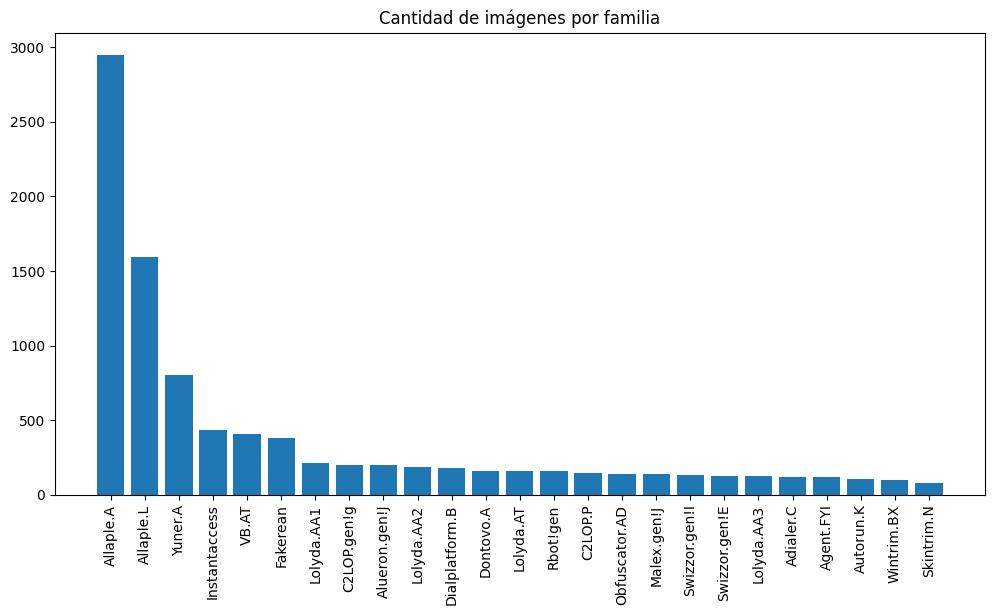

In [10]:
dataset_path = "malimg_paper_dataset_imgs"
families = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

family_counts = {family: len(os.listdir(os.path.join(dataset_path, family))) for family in families}
family_counts = dict(sorted(family_counts.items(), key=lambda item: item[1], reverse=True))

for family, count in family_counts.items():
    print(f"{family}: {count} imágenes")

plt.figure(figsize=(12,6))
plt.bar(family_counts.keys(), family_counts.values())
plt.xticks(rotation=90)
plt.title("Cantidad de imágenes por familia")
plt.show()


2. Plotee algunas imágenes de los ejemplos de malware.

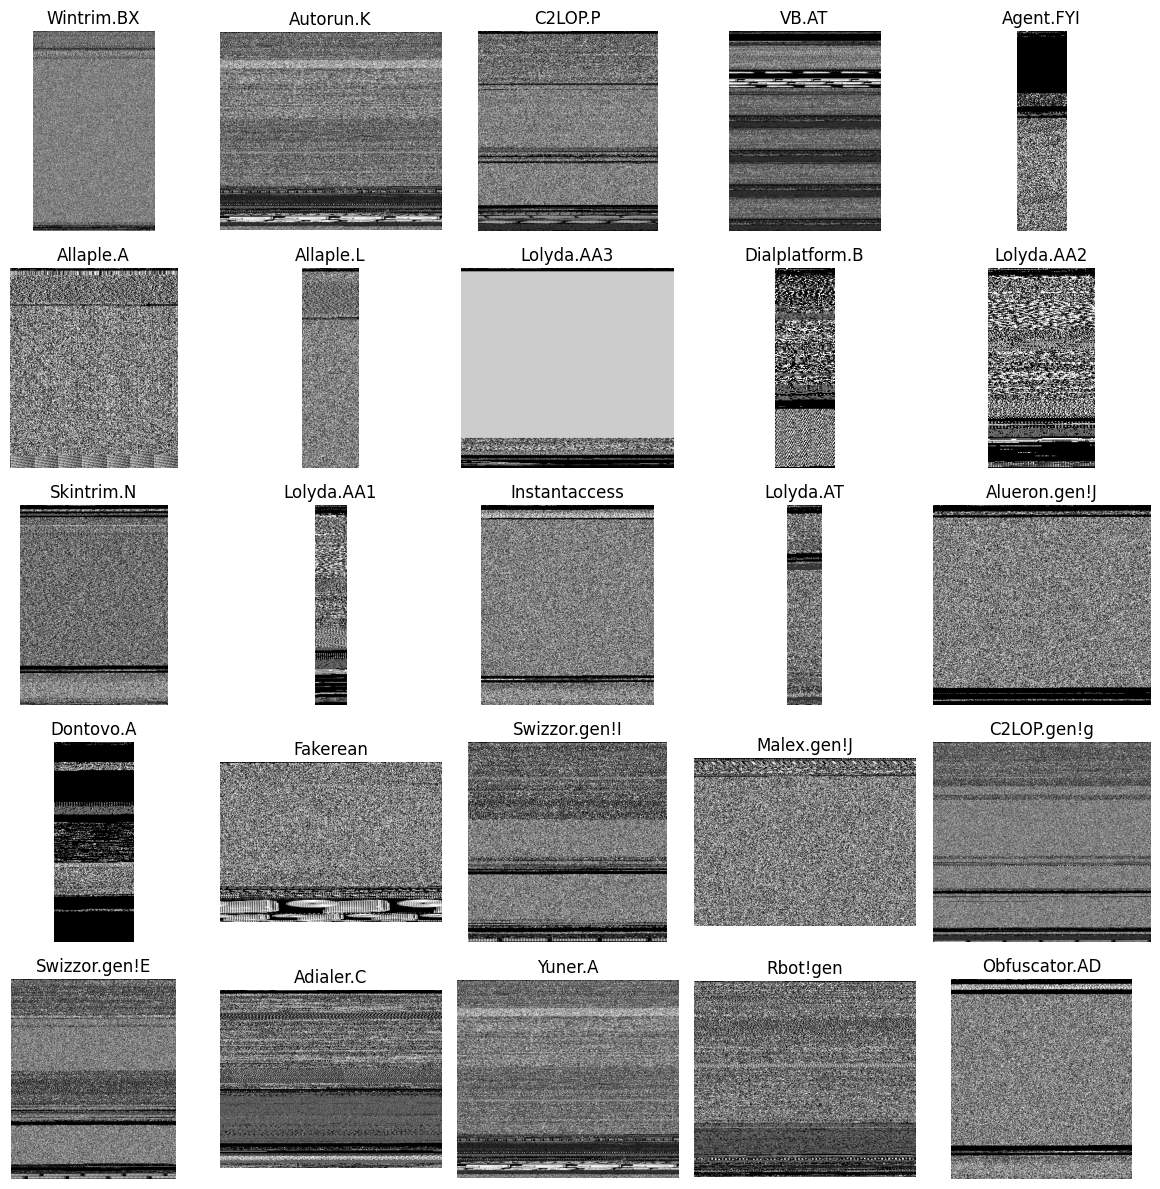

In [11]:
plt.figure(figsize=(12, 12))

for i, family in enumerate(random.sample(families, 25)):
    img_path = os.path.join(dataset_path, family)
    img_file = random.choice(os.listdir(img_path))
    img = mpimg.imread(os.path.join(img_path, img_file))
    plt.subplot(5, 5, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(family)
    plt.axis('off')

plt.tight_layout()
plt.show()

3. Utilizando Keras y Tensorflow construya una red neuronal con las capas, funciones de
activación y el optimizador que considere conveniente.

In [12]:
img_size = (64, 64)

datagen = ImageDataGenerator(
    validation_split=0.3,
    rescale=1./255
)

train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    color_mode="grayscale",
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(64, 64, 1)),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(train_generator.num_classes, activation='softmax')
])


Found 6549 images belonging to 25 classes.
Found 2790 images belonging to 25 classes.


C:\Users\erick\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


4. Muestre el resumen del modelo

In [13]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 62, 62, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 31, 31, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 29, 29, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,605,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 25)             │         3,225 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,627,801 (6.21 MB)

 Trainable params: 1,627,801 (6.21 MB)

 Non-trainable params: 0 (0.00 B)

6. Entrene el modelo con el número de épocas que considere conveniente.

In [14]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator
)

C:\Users\erick\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 148ms/step - accuracy: 0.4649 - loss: 1.8752 - val_accuracy: 0.8749 - val_loss: 0.5285
Epoch 2/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 144ms/step - accuracy: 0.8281 - loss: 0.5703 - val_accuracy: 0.9136 - val_loss: 0.3088
Epoch 3/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 31s 151ms/step - accuracy: 0.8999 - loss: 0.3428 - val_accuracy: 0.9362 - val_loss: 0.2113
Epoch 4/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 158ms/step - accuracy: 0.9318 - loss: 0.2200 - val_accuracy: 0.9534 - val_loss: 0.1718
Epoch 5/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 33s 161ms/step - accuracy: 0.9464 - loss: 0.1746 - val_accuracy: 0.9527 - val_loss: 0.1598
Epoch 6/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 33s 160ms/step - accuracy: 0.9505 - loss: 0.1583 - val_accuracy: 0.9527 - val_loss: 0.1856
Epoch 7/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.9588 - loss: 0.1335 - val_accuracy: 0.9516 - val_loss: 0.1685
Epoch 8/10
205/205 ━━━━━━━━━━━━━━━━━━━━ 32s 156ms/step - accuracy: 0.9575 - loss: 0

7. Muestre las métricas de su modelo.

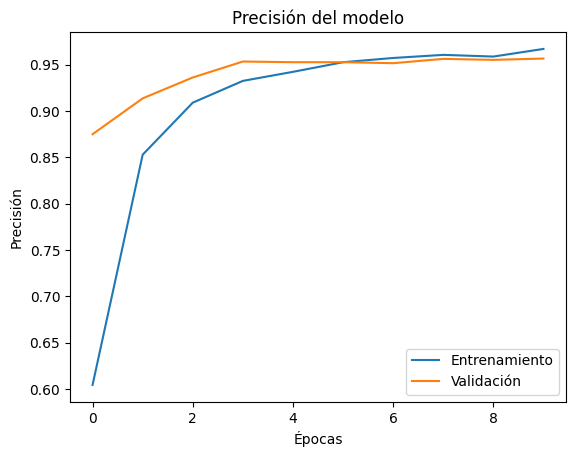

In [15]:
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión del modelo')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()
plt.show()

8. Evalúe el modelo con el dataset de pruebas y muestre las métricas obtenidas. Discuta los
resultados obtenidos.

88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 68ms/step - accuracy: 0.9608 - loss: 0.1887
Loss: 0.1944
Accuracy: 0.9566
88/88 ━━━━━━━━━━━━━━━━━━━━ 6s 67ms/step

Reporte de Clasificación:
                precision    recall  f1-score   support

     Adialer.C       0.00      0.00      0.00        36
     Agent.FYI       0.03      0.03      0.03        34
     Allaple.A       0.32      0.32      0.32       884
     Allaple.L       0.15      0.15      0.15       477
 Alueron.gen!J       0.02      0.02      0.02        59
     Autorun.K       0.00      0.00      0.00        31
       C2LOP.P       0.00      0.00      0.00        43
   C2LOP.gen!g       0.08      0.08      0.08        60
Dialplatform.B       0.04      0.04      0.04        53
     Dontovo.A       0.06      0.06      0.06        48
      Fakerean       0.04      0.04      0.04       114
 Instantaccess       0.04      0.04      0.04       129
    Lolyda.AA1       0.03      0.03      0.03        63
    Lolyda.AA2       0.00      0.00      0.0

c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 1200x1000 with 0 Axes>

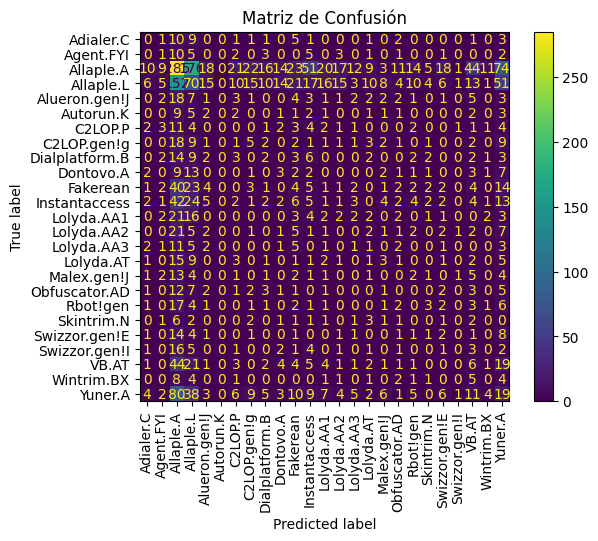

In [16]:
loss, accuracy = model.evaluate(val_generator)
print(f"Loss: {loss:.4f}")
print(f"Accuracy: {accuracy:.4f}")

y_pred_probs = model.predict(val_generator)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("\nReporte de Clasificación:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels).plot(xticks_rotation=90)
plt.title("Matriz de Confusión")
plt.show()